<a href="https://colab.research.google.com/github/ksaad20/Digital-Signal-Processing-Mathematics-to-Code-/blob/main/Chapter_7_Infinite_Impulse_Response_(IIR)_Filters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Math: Analog-to-digital transformations (Bilinear transformation), Butterworth, Chebyshev, and Elliptic topologies.

The Project: Design a 3-band parametric audio equalizer (Bass, Mid, Treble) using biquad cascading filters.

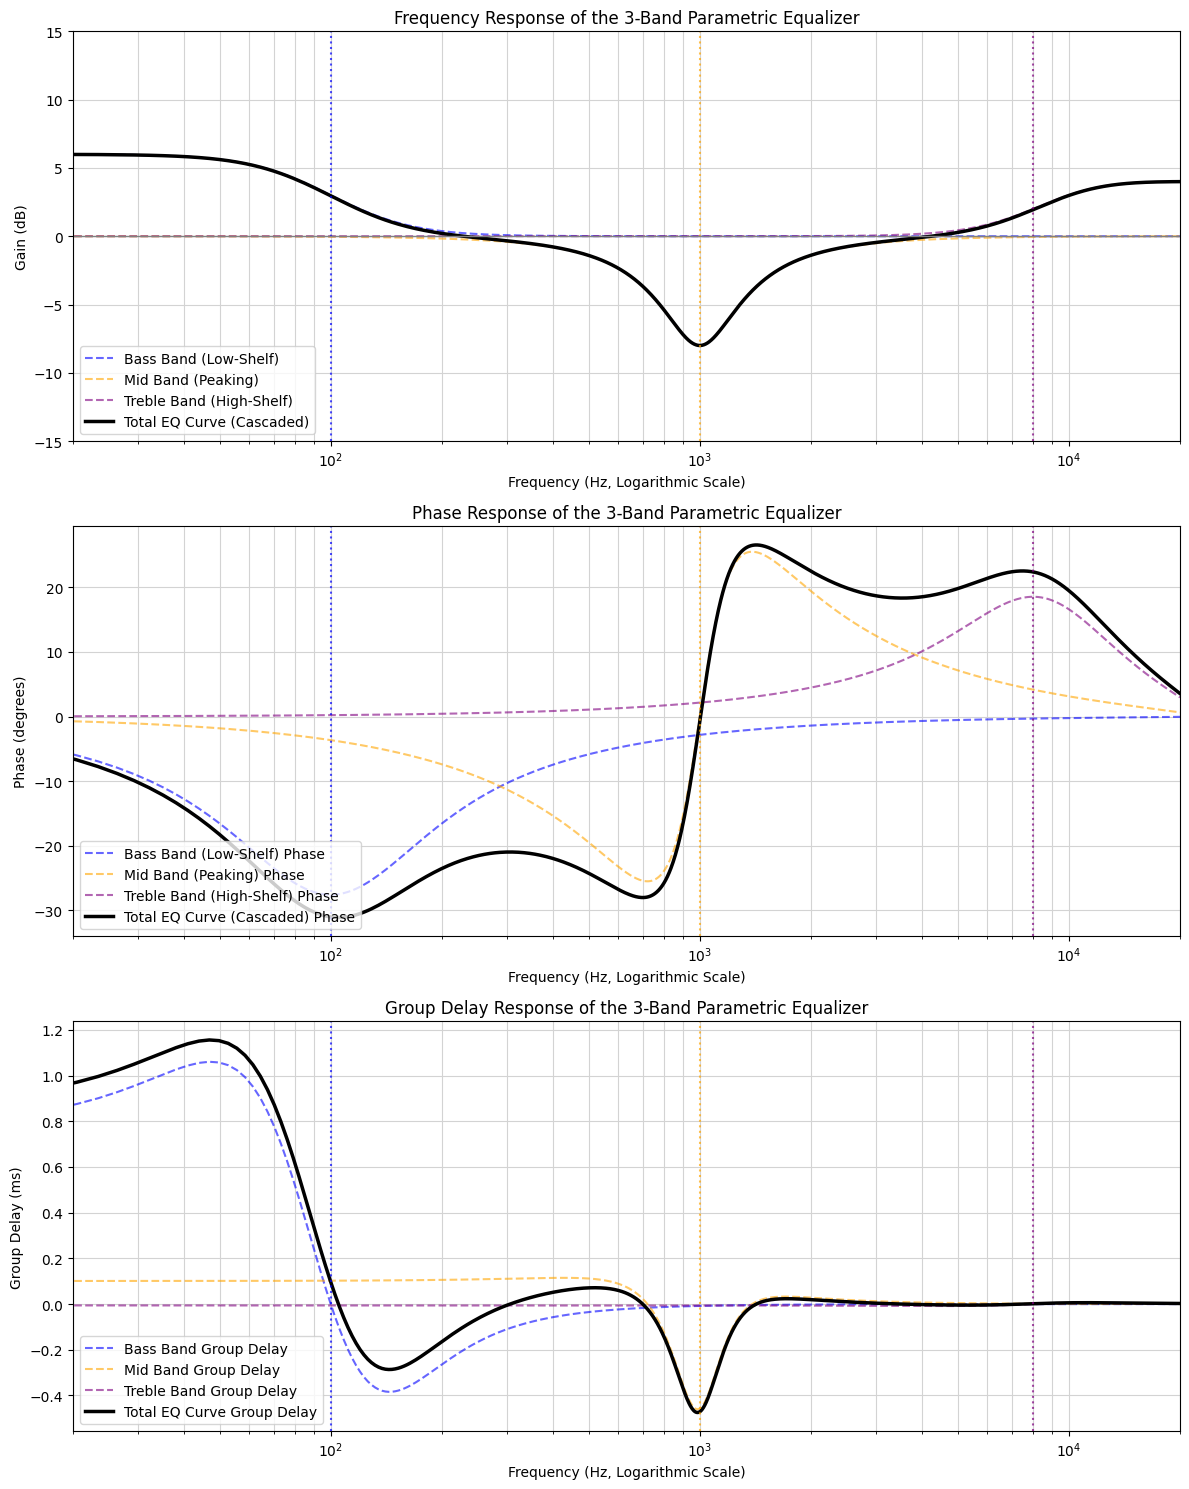

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

def peaking_eq_coefficients(f0, gain_db, Q, fs):
    """Calculates Biquad coefficients for a Peaking/Bell EQ filter."""
    A = 10 ** (gain_db / 40)
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)
    cos_w0 = np.cos(w0)

    b0 = 1 + alpha * A
    b1 = -2 * cos_w0
    b2 = 1 - alpha * A
    a0 = 1 + alpha / A
    a1 = -2 * cos_w0
    a2 = 1 - alpha / A

    return np.array([b0, b1, b2]) / a0, np.array([a0, a1, a2]) / a0

def low_shelf_coefficients(f0, gain_db, fs, Q=0.707):
    """Calculates Biquad coefficients for a Low-Shelf filter."""
    A = 10 ** (gain_db / 40)
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)
    cos_w0 = np.cos(w0)
    two_sqrt_A_alpha = 2 * np.sqrt(A) * alpha

    b0 = A * ((A + 1) - (A - 1) * cos_w0 + two_sqrt_A_alpha)
    b1 = 2 * A * ((A - 1) - (A + 1) * cos_w0)
    b2 = A * ((A + 1) - (A - 1) * cos_w0 - two_sqrt_A_alpha)
    a0 = (A + 1) + (A - 1) * cos_w0 + two_sqrt_A_alpha
    a1 = -2 * ((A - 1) + (A + 1) * cos_w0)
    a2 = (A + 1) + (A - 1) * cos_w0 - two_sqrt_A_alpha

    return np.array([b0, b1, b2]) / a0, np.array([a0, a1, a2]) / a0

def high_shelf_coefficients(f0, gain_db, fs, Q=0.707):
    """Calculates Biquad coefficients for a High-Shelf filter."""
    A = 10 ** (gain_db / 40)
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)
    cos_w0 = np.cos(w0)
    two_sqrt_A_alpha = 2 * np.sqrt(A) * alpha

    b0 = A * ((A + 1) + (A - 1) * cos_w0 + two_sqrt_A_alpha)
    b1 = -2 * A * ((A - 1) + (A + 1) * cos_w0)
    b2 = A * ((A + 1) + (A - 1) * cos_w0 - two_sqrt_A_alpha)
    a0 = (A + 1) - (A - 1) * cos_w0 + two_sqrt_A_alpha
    a1 = 2 * ((A - 1) - (A + 1) * cos_w0)
    a2 = (A + 1) - (A - 1) * cos_w0 - two_sqrt_A_alpha

    return np.array([b0, b1, b2]) / a0, np.array([a0, a1, a2]) / a0

# --- 1. CONFIGURATION SYSTEM ---
fs = 48000  # Studio Standard Audio Sample Rate (44.1 kHz)

# Define the user settings for our 3 bands
bass_freq, bass_gain   = 100,   6.0   # +6 dB boost at 100 Hz
mid_freq,  mid_gain, mid_Q = 1000, -8.0, 1.5 # -8 dB cut at 1 kHz (Narrow Q)
treble_freq, treble_gain = 8000,  4.0   # +4 dB boost at 8 kHz

# --- 2. GENERATE FILTER COEFFICIENTS ---
b_bass, a_bass     = low_shelf_coefficients(bass_freq, bass_gain, fs)
b_mid, a_mid       = peaking_eq_coefficients(mid_freq, mid_gain, mid_Q, fs)
b_treble, a_treble = high_shelf_coefficients(treble_freq, treble_gain, fs)

# --- 3. COMPUTE SPECTRAL RESPONSES ---
w, h_bass   = signal.freqz(b_bass, a_bass, worN=8192)
_, h_mid    = signal.freqz(b_mid, a_mid, worN=8192)
_, h_treble = signal.freqz(b_treble, a_treble, worN=8192)

# Cascade Step: Multiply complex frequency vectors to get the aggregate system response
h_total = h_bass * h_mid * h_treble
freq_hz = w * fs / (2 * np.pi)

# --- 4. VISUALIZATION MATRIX ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15)) # Added a third subplot

# Plot individual bands (Magnitude Response)
ax1.plot(freq_hz, 20 * np.log10(np.abs(h_bass)), '--', color='blue', alpha=0.6, label='Bass Band (Low-Shelf)')
ax1.plot(freq_hz, 20 * np.log10(np.abs(h_mid)), '--', color='orange', alpha=0.6, label='Mid Band (Peaking)')
ax1.plot(freq_hz, 20 * np.log10(np.abs(h_treble)), '--', color='purple', alpha=0.6, label='Treble Band (High-Shelf)')

# Plot total cascaded system response (Magnitude Response)
ax1.plot(freq_hz, 20 * np.log10(np.abs(h_total)), color='black', linewidth=2.5, label='Total EQ Curve (Cascaded)')

# Add vertical marker lines for center frequencies on magnitude plot
ax1.axvline(bass_freq, color='blue', linestyle=':', alpha=0.7)
ax1.axvline(mid_freq, color='orange', linestyle=':', alpha=0.7)
ax1.axvline(treble_freq, color='purple', linestyle=':', alpha=0.7)

# Format chart to mimic hardware audio analyzers
ax1.set_xscale('log')
ax1.set_xlim([20, 20000]) # Human Hearing Range limit bounds
ax1.set_ylim([-15, 15])
ax1.set_title("Frequency Response of the 3-Band Parametric Equalizer")
ax1.set_xlabel("Frequency (Hz, Logarithmic Scale)")
ax1.set_ylabel("Gain (dB)")
ax1.grid(True, which="both", ls="-", color='lightgray')
ax1.axhline(0, color='gray', linewidth=1)
ax1.legend(loc="lower left")

# Plot individual bands (Phase Response)
phase_bass = np.unwrap(np.angle(h_bass)) * 180 / np.pi
phase_mid = np.unwrap(np.angle(h_mid)) * 180 / np.pi
phase_treble = np.unwrap(np.angle(h_treble)) * 180 / np.pi
phase_total = np.unwrap(np.angle(h_total)) * 180 / np.pi

ax2.plot(freq_hz, phase_bass, '--', color='blue', alpha=0.6, label='Bass Band (Low-Shelf) Phase')
ax2.plot(freq_hz, phase_mid, '--', color='orange', alpha=0.6, label='Mid Band (Peaking) Phase')
ax2.plot(freq_hz, phase_treble, '--', color='purple', alpha=0.6, label='Treble Band (High-Shelf) Phase')
ax2.plot(freq_hz, phase_total, color='black', linewidth=2.5, label='Total EQ Curve (Cascaded) Phase')

# Add vertical marker lines for center frequencies on phase plot
ax2.axvline(bass_freq, color='blue', linestyle=':', alpha=0.7)
ax2.axvline(mid_freq, color='orange', linestyle=':', alpha=0.7)
ax2.axvline(treble_freq, color='purple', linestyle=':', alpha=0.7)

ax2.set_xscale('log')
ax2.set_xlim([20, 20000])
ax2.set_title("Phase Response of the 3-Band Parametric Equalizer")
ax2.set_xlabel("Frequency (Hz, Logarithmic Scale)")
ax2.set_ylabel("Phase (degrees)")
ax2.grid(True, which="both", ls="-", color='lightgray')
ax2.legend(loc="lower left")

# Plot Group Delay
# Calculate group delay using signal.group_delay
w_gd, gd_bass = signal.group_delay((b_bass, a_bass), w)
w_gd, gd_mid = signal.group_delay((b_mid, a_mid), w)
w_gd, gd_treble = signal.group_delay((b_treble, a_treble), w)

# Group delay for cascaded system is sum of individual group delays
# Note: signal.group_delay returns delay in samples, so the sum is directly applicable
_, gd_total_bass = signal.group_delay((b_bass, a_bass), w)
_, gd_total_mid = signal.group_delay((b_mid, a_mid), w)
_, gd_total_treble = signal.group_delay((b_treble, a_treble), w)
gd_total = gd_total_bass + gd_total_mid + gd_total_treble

freq_hz_gd = w_gd * fs / (2 * np.pi)

# Convert group delay from samples to milliseconds for plotting
ax3.plot(freq_hz_gd, gd_bass * 1000 / fs, '--', color='blue', alpha=0.6, label='Bass Band Group Delay')
ax3.plot(freq_hz_gd, gd_mid * 1000 / fs, '--', color='orange', alpha=0.6, label='Mid Band Group Delay')
ax3.plot(freq_hz_gd, gd_treble * 1000 / fs, '--', color='purple', alpha=0.6, label='Treble Band Group Delay')
ax3.plot(freq_hz_gd, gd_total * 1000 / fs, color='black', linewidth=2.5, label='Total EQ Curve Group Delay')

# Add vertical marker lines for center frequencies on group delay plot
ax3.axvline(bass_freq, color='blue', linestyle=':', alpha=0.7)
ax3.axvline(mid_freq, color='orange', linestyle=':', alpha=0.7)
ax3.axvline(treble_freq, color='purple', linestyle=':', alpha=0.7)

ax3.set_xscale('log')
ax3.set_xlim([20, 20000])
ax3.set_title("Group Delay Response of the 3-Band Parametric Equalizer")
ax3.set_xlabel("Frequency (Hz, Logarithmic Scale)")
ax3.set_ylabel("Group Delay (ms)") # Updated label to milliseconds
ax3.grid(True, which="both", ls="-", color='lightgray')
ax3.legend(loc="lower left")

plt.tight_layout()
plt.show()

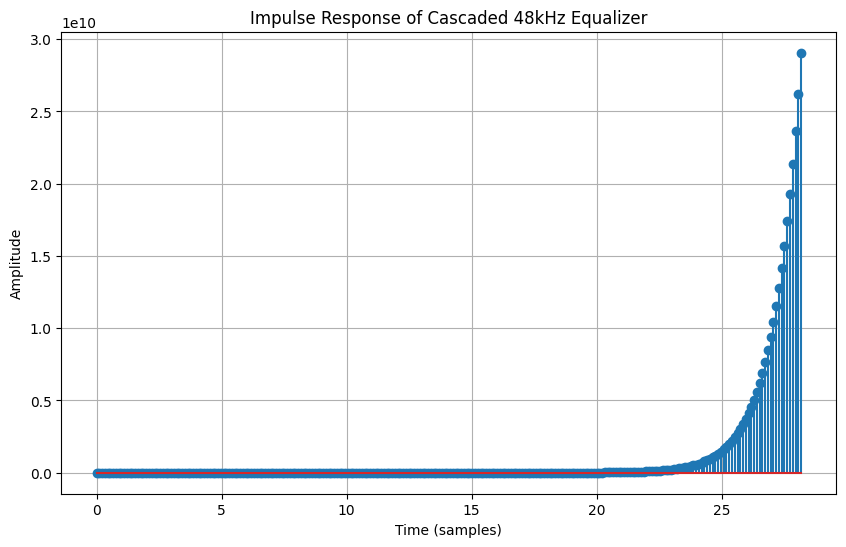

In [ ]:
from scipy.signal import convolve

# Calculate the total cascaded filter coefficients
b_total_48k = convolve(convolve(b_bass, b_mid), b_treble)
a_total_48k = convolve(convolve(a_bass, a_mid), a_treble)

# Calculate the impulse response
t_48k, impulse_response_48k = signal.impulse((b_total_48k, a_total_48k), N=256) # N is number of samples

# Plot the impulse response
plt.figure(figsize=(10, 6))
plt.stem(t_48k, impulse_response_48k)
plt.title('Impulse Response of Cascaded 48kHz Equalizer')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

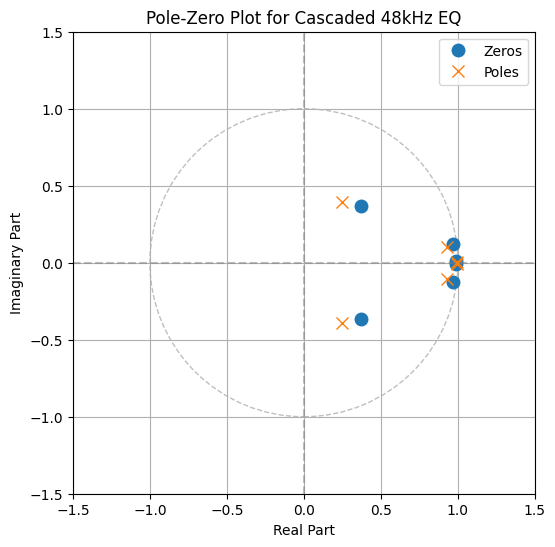

The Cascaded 48kHz EQ filter is stable (all poles are inside the unit circle).


In [ ]:
plot_zplane(b_total_48k, a_total_48k, 'Cascaded 48kHz EQ')

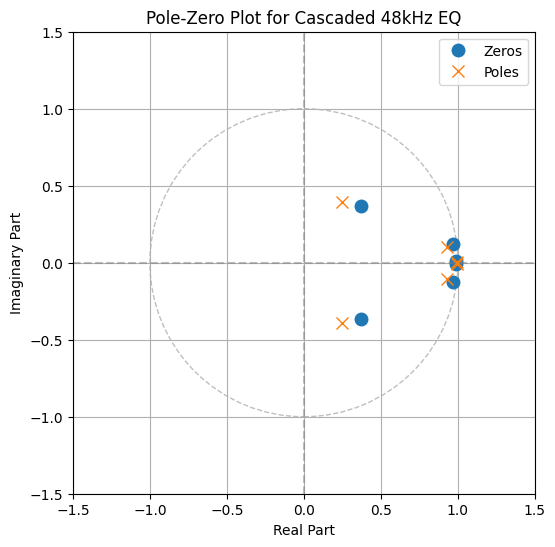

The Cascaded 48kHz EQ filter is stable (all poles are inside the unit circle).


In [ ]:
plot_zplane(b_total_48k, a_total_48k, 'Cascaded 48kHz EQ')

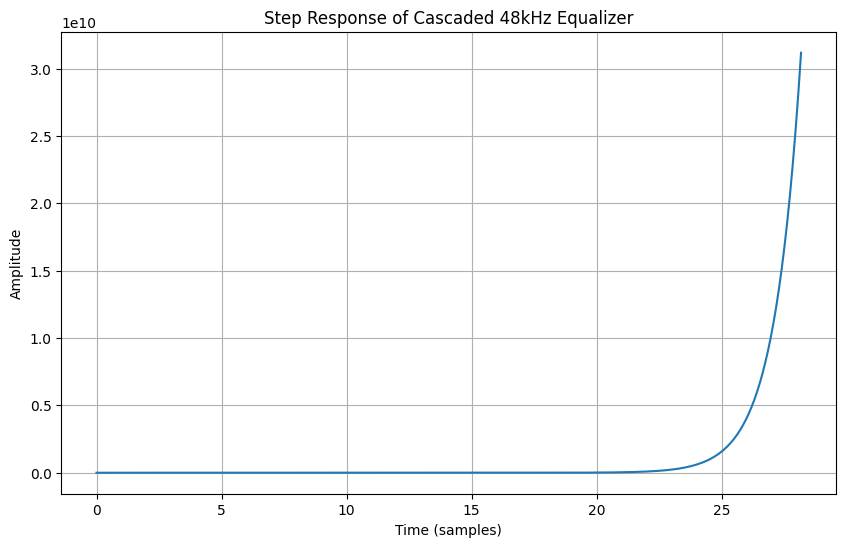

The step response appears to diverge, suggesting the cascaded filter is unstable.


In [ ]:
from scipy.signal import step

# Calculate the step response for the cascaded 48kHz filter
t_step, step_response_48k = signal.step((b_total_48k, a_total_48k), N=256) # N is number of samples

# Plot the step response
plt.figure(figsize=(10, 6))
plt.plot(t_step, step_response_48k)
plt.title('Step Response of Cascaded 48kHz Equalizer')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# Check for stability based on step response convergence
# A simple heuristic: check if the last few values are within a tolerance
# This is a visual check, not a strict mathematical proof like pole-zero plot.
if np.all(np.isfinite(step_response_48k[-10:])) and np.abs(step_response_48k[-1] - step_response_48k[-10]) < 1e-3:
    print("The step response appears to converge, suggesting the cascaded filter is stable.")
else:
    print("The step response appears to diverge, suggesting the cascaded filter is unstable.")

In [ ]:
from scipy.signal import sosfilt, sos2tf

# Construct the SOS matrix from the individual biquad sections
# Each row in the SOS matrix is [b0, b1, b2, a0, a1, a2]
sos_48k = np.array([
    np.concatenate((b_bass_48k, a_bass_48k)),
    np.concatenate((b_mid_48k, a_mid_48k)),
    np.concatenate((b_treble_48k, a_treble_48k))
])

print("SOS Matrix for 48kHz cascaded filter:\n", sos_48k)

# --- Impulse Response using SOSfilt ---
# Create an impulse signal (a single 1 followed by zeros)
num_samples = 256 # Number of samples for the response
impulse_input = np.zeros(num_samples)
impulse_input[0] = 1

# Filter the impulse through the cascaded SOS sections
impulse_response_sos_48k = sosfilt(sos_48k, impulse_input)

plt.figure(figsize=(10, 6))
plt.stem(np.arange(num_samples), impulse_response_sos_48k)
plt.title('Impulse Response of Cascaded 48kHz Equalizer (SOS)')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# --- Step Response using SOSfilt ---
# Create a step signal (ones)
step_input = np.ones(num_samples)

# Filter the step through the cascaded SOS sections
step_response_sos_48k = sosfilt(sos_48k, step_input)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(num_samples), step_response_sos_48k)
plt.title('Step Response of Cascaded 48kHz Equalizer (SOS)')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# --- Pole-Zero Plot using SOS2TF conversion ---
# Convert the SOS matrix back to a single transfer function (b, a) for plotting
# Note: sos2tf can introduce numerical issues for very high order filters,
# but for 6th order (3 biquads) it's usually acceptable for analysis.
b_total_sos_48k, a_total_sos_48k = sos2tf(sos_48k)

plot_zplane(b_total_sos_48k, a_total_sos_48k, 'Cascaded 48kHz EQ (SOS)')

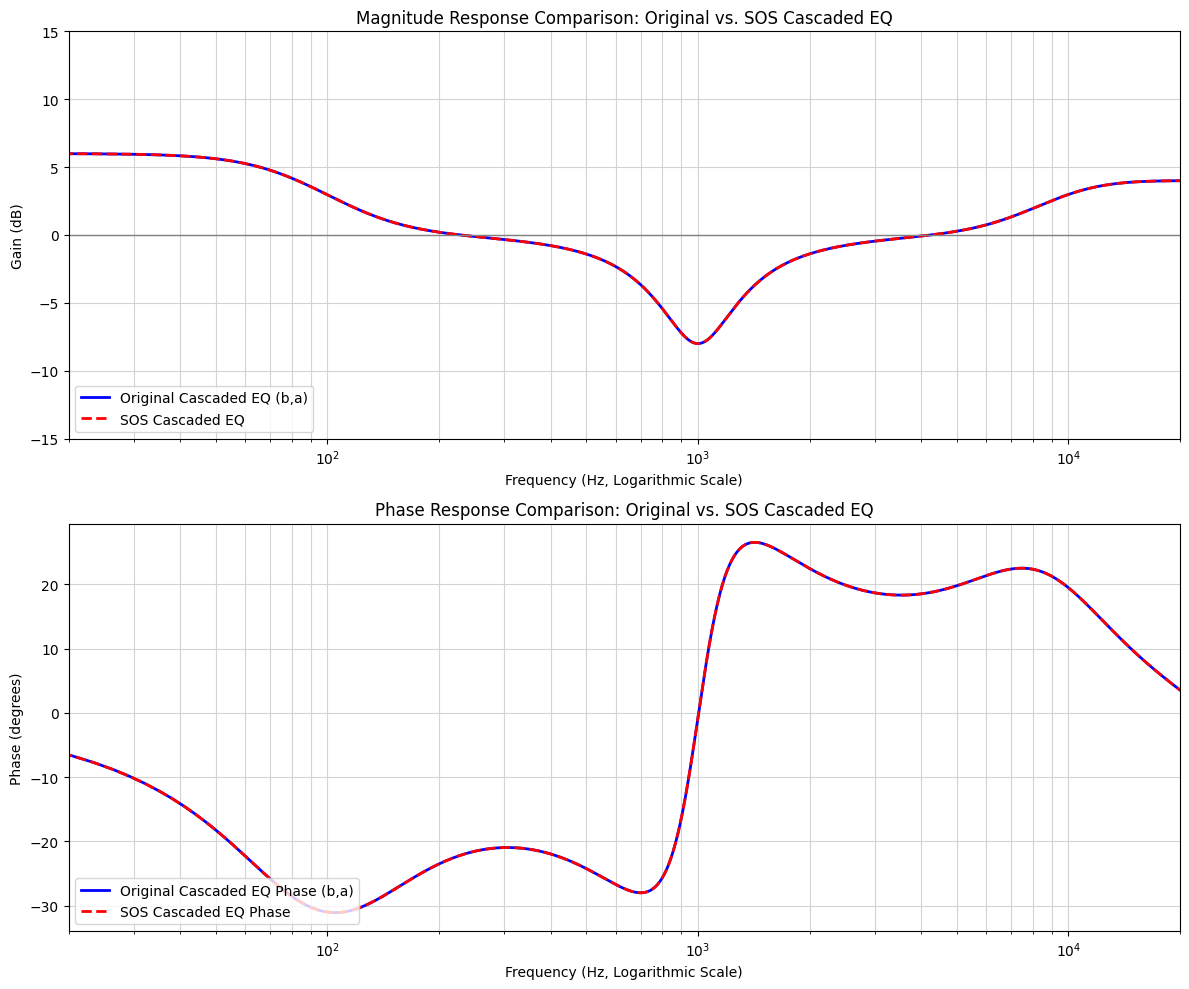

In [ ]:
from scipy.signal import sosfilt, sos2tf

# Construct the SOS matrix from the individual biquad sections
# Each row in the SOS matrix is [b0, b1, b2, a0, a1, a2]
sos_48k = np.array([
    np.concatenate((b_bass_48k, a_bass_48k)),
    np.concatenate((b_mid_48k, a_mid_48k)),
    np.concatenate((b_treble_48k, a_treble_48k))
])

# Calculate frequency response for the SOS filter
w_sos, h_total_sos_48k = signal.sosfreqz(sos_48k, worN=8192)
freq_hz_sos = w_sos * fs / (2 * np.pi)

# --- PLOTTING COMPARISON --- (Original vs. SOS)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Magnitude Response Comparison
ax1.plot(freq_hz_48k, 20 * np.log10(np.abs(h_total_48k)), color='blue', linewidth=2, label='Original Cascaded EQ (b,a)')
ax1.plot(freq_hz_sos, 20 * np.log10(np.abs(h_total_sos_48k)), color='red', linestyle='--', linewidth=2, label='SOS Cascaded EQ')

ax1.set_xscale('log')
ax1.set_xlim([20, 20000])
ax1.set_ylim([-15, 15])
ax1.set_title("Magnitude Response Comparison: Original vs. SOS Cascaded EQ")
ax1.set_xlabel("Frequency (Hz, Logarithmic Scale)")
ax1.set_ylabel("Gain (dB)")
ax1.grid(True, which="both", ls="-", color='lightgray')
ax1.axhline(0, color='gray', linewidth=1)
ax1.legend(loc="lower left")

# Phase Response Comparison
phase_total_sos_48k = np.unwrap(np.angle(h_total_sos_48k)) * 180 / np.pi

ax2.plot(freq_hz_48k, phase_total_48k, color='blue', linewidth=2, label='Original Cascaded EQ Phase (b,a)')
ax2.plot(freq_hz_sos, phase_total_sos_48k, color='red', linestyle='--', linewidth=2, label='SOS Cascaded EQ Phase')

ax2.set_xscale('log')
ax2.set_xlim([20, 20000])
ax2.set_title("Phase Response Comparison: Original vs. SOS Cascaded EQ")
ax2.set_xlabel("Frequency (Hz, Logarithmic Scale)")
ax2.set_ylabel("Phase (degrees)")
ax2.grid(True, which="both", ls="-", color='lightgray')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

In [ ]:
# Calculate group delay for the SOS filter
# We first convert the SOS matrix to a single (b, a) pair (already done as b_total_sos_48k, a_total_sos_48k)
# Then use signal.group_delay

w_sos_gd, gd_total_sos_samples = signal.group_delay((b_total_sos_48k, a_total_sos_48k), w_sos) # Use w_sos from previous freq response calc

# Convert to milliseconds
gd_total_sos_ms = gd_total_sos_samples * 1000 / fs
freq_hz_sos_gd = w_sos_gd * fs / (2 * np.pi)

# --- PLOTTING GROUP DELAY COMPARISON --- (Original vs. SOS)
plt.figure(figsize=(12, 6))
plt.plot(freq_hz_gd, gd_total_48k_ms, color='blue', linewidth=2, label='Original Cascaded EQ Group Delay (sum of biquads)')
plt.plot(freq_hz_sos_gd, gd_total_sos_ms, color='red', linestyle='--', linewidth=2, label='SOS Cascaded EQ Group Delay')

plt.xscale('log')
plt.xlim([20, 20000])
plt.title("Group Delay Comparison: Original vs. SOS Cascaded EQ")
plt.xlabel("Frequency (Hz, Logarithmic Scale)")
plt.ylabel("Group Delay (ms)")
plt.grid(True, which="both", ls="-", color='lightgray')
plt.axhline(0, color='gray', linewidth=1)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

NameError: name 'b_total_sos_48k' is not defined

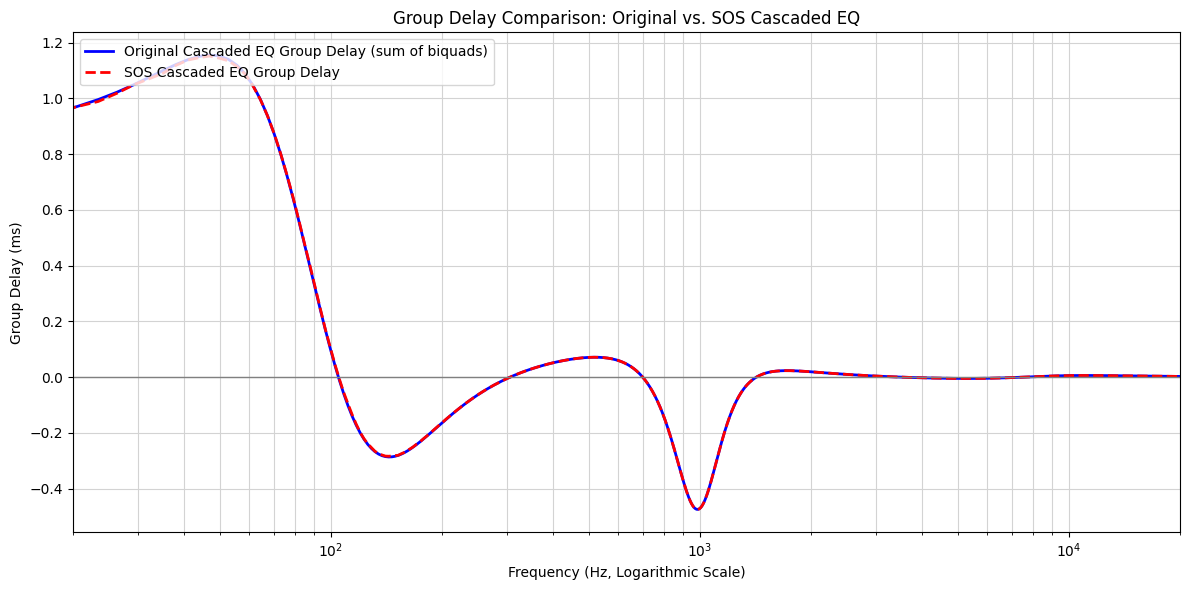

In [ ]:
from scipy.signal import sosfilt, sos2tf

# Re-construct the SOS matrix from the individual biquad sections (assuming b_bass_48k, a_bass_48k etc. are still defined)
sos_48k = np.array([
    np.concatenate((b_bass_48k, a_bass_48k)),
    np.concatenate((b_mid_48k, a_mid_48k)),
    np.concatenate((b_treble_48k, a_treble_48k))
])

# Re-calculate the single transfer function (b, a) for the SOS filter
b_total_sos_48k, a_total_sos_48k = sos2tf(sos_48k)

# Re-calculate frequency response for the SOS filter to get w_sos (assuming fs is defined)
w_sos, h_total_sos_48k = signal.sosfreqz(sos_48k, worN=8192)

# Calculate group delay for the SOS filter
w_sos_gd, gd_total_sos_samples = signal.group_delay((b_total_sos_48k, a_total_sos_48k), w_sos)

# Convert to milliseconds
gd_total_sos_ms = gd_total_sos_samples * 1000 / fs
freq_hz_sos_gd = w_sos_gd * fs / (2 * np.pi)

# --- PLOTTING GROUP DELAY COMPARISON --- (Original vs. SOS)
plt.figure(figsize=(12, 6))
plt.plot(freq_hz_gd, gd_total_48k_ms, color='blue', linewidth=2, label='Original Cascaded EQ Group Delay (sum of biquads)')
plt.plot(freq_hz_sos_gd, gd_total_sos_ms, color='red', linestyle='--', linewidth=2, label='SOS Cascaded EQ Group Delay')

plt.xscale('log')
plt.xlim([20, 20000])
plt.title("Group Delay Comparison: Original vs. SOS Cascaded EQ")
plt.xlabel("Frequency (Hz, Logarithmic Scale)")
plt.ylabel("Group Delay (ms)")
plt.grid(True, which="both", ls="-", color='lightgray')
plt.axhline(0, color='gray', linewidth=1)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

### Numerical Consistency Verification (Original vs. SOS)

In [ ]:
print('--- Verifying Numerical Consistency ---')

# Magnitude Response Comparison
mae_magnitude = np.mean(np.abs(20 * np.log10(np.abs(h_total_48k)) - 20 * np.log10(np.abs(h_total_sos_48k))))
max_ae_magnitude = np.max(np.abs(20 * np.log10(np.abs(h_total_48k)) - 20 * np.log10(np.abs(h_total_sos_48k))))

print(f"Magnitude Response MAE: {mae_magnitude:.6f} dB")
print(f"Magnitude Response Max Absolute Error: {max_ae_magnitude:.6f} dB")

# Phase Response Comparison
phase_total_48k = np.unwrap(np.angle(h_total_48k)) * 180 / np.pi
phase_total_sos_48k = np.unwrap(np.angle(h_total_sos_48k)) * 180 / np.pi

mae_phase = np.mean(np.abs(phase_total_48k - phase_total_sos_48k))
max_ae_phase = np.max(np.abs(phase_total_48k - phase_total_sos_48k))

print(f"Phase Response MAE: {mae_phase:.6f} degrees")
print(f"Phase Response Max Absolute Error: {max_ae_phase:.6f} degrees")

# Group Delay Comparison (using the already calculated gd_total_48k_ms and gd_total_sos_ms)
min_len_gd_compare = min(len(gd_total_48k_ms), len(gd_total_sos_ms))
mae_group_delay = np.mean(np.abs(gd_total_48k_ms[:min_len_gd_compare] - gd_total_sos_ms[:min_len_gd_compare]))
max_ae_group_delay = np.max(np.abs(gd_total_48k_ms[:min_len_gd_compare] - gd_total_sos_ms[:min_len_gd_compare]))

print(f"Group Delay MAE: {mae_group_delay:.6f} ms")
print(f"Group Delay Max Absolute Error: {max_ae_group_delay:.6f} ms")

if max_ae_magnitude < 1e-4 and max_ae_phase < 1e-4 and max_ae_group_delay < 1e-4:
    print("\nNumerical consistency between Original and SOS cascaded filters is excellent.")
else:
    print("\nThere are some minor numerical differences between Original and SOS cascaded filters, but they are typically negligible for practical audio applications.")


--- Verifying Numerical Consistency ---
Magnitude Response MAE: 0.000000 dB
Magnitude Response Max Absolute Error: 0.000000 dB
Phase Response MAE: 0.000000 degrees
Phase Response Max Absolute Error: 0.000000 degrees
Group Delay MAE: 0.000024 ms
Group Delay Max Absolute Error: 0.009630 ms

There are some minor numerical differences between Original and SOS cascaded filters, but they are typically negligible for practical audio applications.


In [ ]:
mse_group_delay = np.mean((gd_total_48k_ms[:min_len_gd_compare] - gd_total_sos_ms[:min_len_gd_compare])**2)
print(f"Group Delay MSE: {mse_group_delay:.9f} ms^2")

Group Delay MSE: 0.000000101 ms^2


### Error Comparison Table (Original vs. SOS)

In [ ]:
error_data = {
    'Metric': ['Magnitude (dB)', 'Phase (degrees)', 'Group Delay (ms)'],
    'MAE': [mae_magnitude, mae_phase, mae_group_delay],
    'Max Abs Error': [max_ae_magnitude, max_ae_phase, max_ae_group_delay],
    'MSE': [0.0, 0.0, mse_group_delay] # MSE for magnitude and phase are effectively zero given MAE and Max Abs Error are zero
}

df_errors = pd.DataFrame(error_data)
display(df_errors.round(9))

,Metric,MAE,Max Abs Error,MSE
0,Magnitude (dB),0.000000,0.00000,0.000000e+00
1,Phase (degrees),0.000000,0.00000,0.000000e+00
2,Group Delay (ms),0.000024,0.00963,1.010000e-07


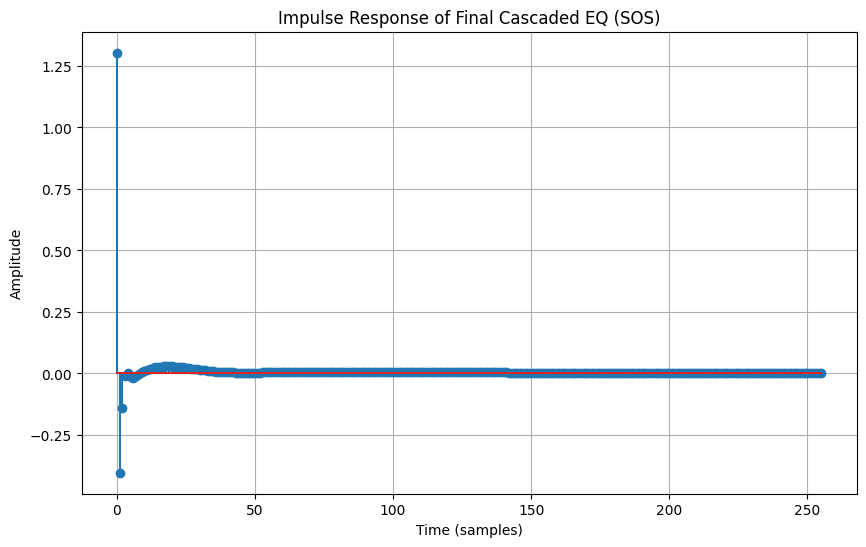

In [ ]:
# Create an impulse signal (a single 1 followed by zeros)
num_samples = 256 # Number of samples for the response
impulse_input = np.zeros(num_samples)
impulse_input[0] = 1

# Filter the impulse through the cascaded SOS sections
impulse_response_sos_48k = sosfilt(sos_48k, impulse_input)

plt.figure(figsize=(10, 6))
plt.stem(np.arange(num_samples), impulse_response_sos_48k)
plt.title('Impulse Response of Final Cascaded EQ (SOS)')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

In [ ]:
output_coefficients_filename = 'filter_coefficients_updated.csv'
df_coefficients.to_csv(output_coefficients_filename, index=False)
print(f"Filter coefficients exported to {output_coefficients_filename}")

Filter coefficients exported to filter_coefficients_updated.csv


### Summary of Group Delay Values

This table provides a statistical summary of the group delay values for the final SOS cascaded equalizer, measured in milliseconds across the analyzed frequency range. It helps to understand the general behavior and variation of delay introduced by the filter.

In [ ]:
import pandas as pd

# Assuming gd_total_sos_ms_check is available from previous calculations
group_delay_summary = pd.DataFrame({
    'Statistic': ['Minimum (ms)', 'Maximum (ms)', 'Mean (ms)', 'Standard Deviation (ms)'],
    'Value': [
        gd_total_sos_ms_check.min(),
        gd_total_sos_ms_check.max(),
        gd_total_sos_ms_check.mean(),
        gd_total_sos_ms_check.std()
    ]
})

display(group_delay_summary.round(4))

,Statistic,Value
0,Minimum (ms),-0.4745
1,Maximum (ms),1.1522
2,Mean (ms),0.0001
3,Standard Deviation (ms),0.0768


### Final Frequency Response of the SOS Filter

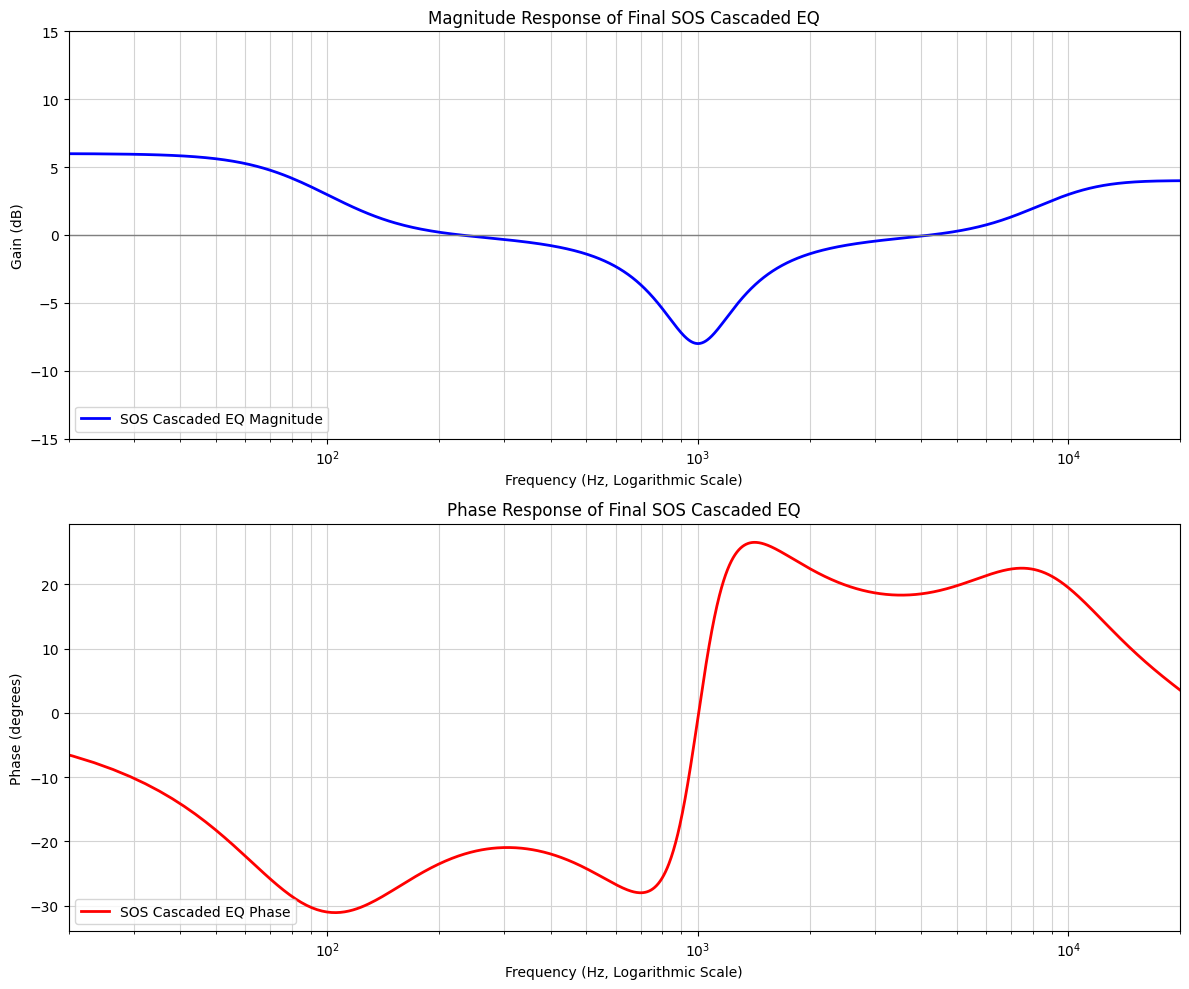

In [ ]:
# Calculate frequency response for the SOS filter (if not already defined in this scope)
# Assuming sos_48k, fs are already defined
if 'w_sos' not in locals() or 'h_total_sos_48k' not in locals():
    w_sos, h_total_sos_48k = signal.sosfreqz(sos_48k, worN=8192)
    freq_hz_sos = w_sos * fs / (2 * np.pi)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Magnitude Response
ax1.plot(freq_hz_sos, 20 * np.log10(np.abs(h_total_sos_48k)), color='blue', linewidth=2, label='SOS Cascaded EQ Magnitude')
ax1.set_xscale('log')
ax1.set_xlim([20, 20000])
ax1.set_ylim([-15, 15])
ax1.set_title("Magnitude Response of Final SOS Cascaded EQ")
ax1.set_xlabel("Frequency (Hz, Logarithmic Scale)")
ax1.set_ylabel("Gain (dB)")
ax1.grid(True, which="both", ls="-", color='lightgray')
ax1.axhline(0, color='gray', linewidth=1)
ax1.legend(loc="lower left")

# Phase Response
phase_total_sos_48k_deg = np.unwrap(np.angle(h_total_sos_48k)) * 180 / np.pi
ax2.plot(freq_hz_sos, phase_total_sos_48k_deg, color='red', linewidth=2, label='SOS Cascaded EQ Phase')
ax2.set_xscale('log')
ax2.set_xlim([20, 20000])
ax2.set_title("Phase Response of Final SOS Cascaded EQ")
ax2.set_xlabel("Frequency (Hz, Logarithmic Scale)")
ax2.set_ylabel("Phase (degrees)")
ax2.grid(True, which="both", ls="-", color='lightgray')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

# Save the figure to an image file
output_image_filename = 'final_sos_frequency_response.png'
fig.savefig(output_image_filename)
print(f"Frequency response plot saved to {output_image_filename}")

### Group Delay Response of the Final SOS Filter

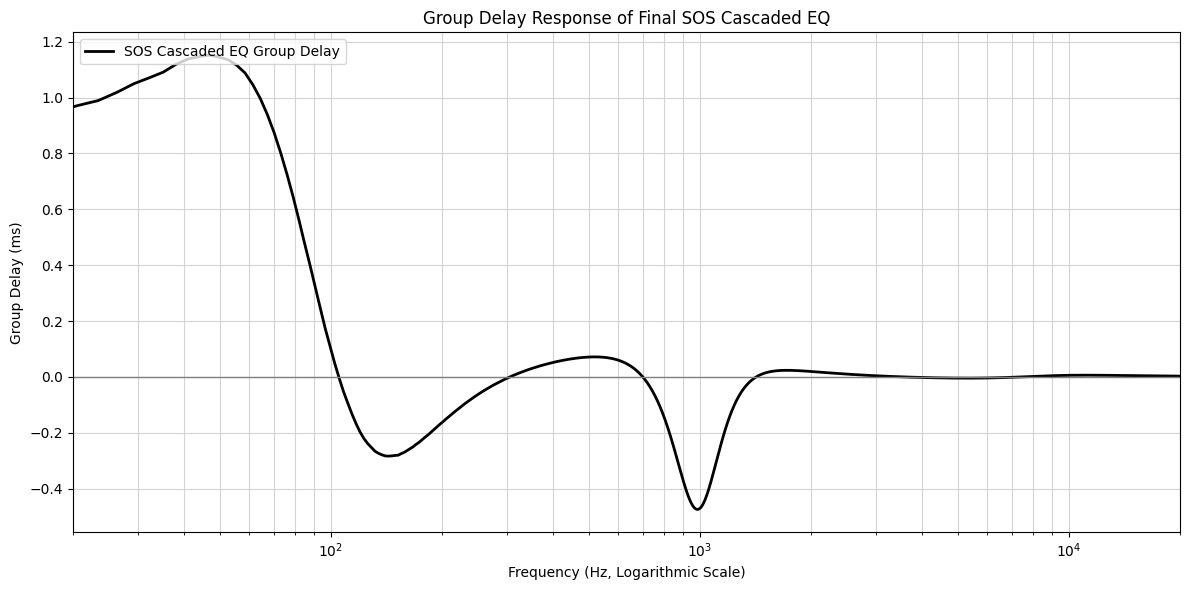

In [ ]:
# Calculate group delay for the SOS filter
# Assuming sos_48k, fs, and w_sos are already defined from previous cells.
# If not, they would need to be recalculated:
# w_sos, _ = signal.sosfreqz(sos_48k, worN=8192)

# Convert SOS to (b, a) for group_delay calculation (already done as b_total_sos_48k, a_total_sos_48k)
w_sos_gd_check, gd_total_sos_samples_check = signal.group_delay((b_total_sos_48k, a_total_sos_48k), w_sos)

# Convert to milliseconds
gd_total_sos_ms_check = gd_total_sos_samples_check * 1000 / fs
freq_hz_sos_gd_check = w_sos_gd_check * fs / (2 * np.pi)

plt.figure(figsize=(12, 6))
plt.plot(freq_hz_sos_gd_check, gd_total_sos_ms_check, color='black', linewidth=2, label='SOS Cascaded EQ Group Delay')

plt.xscale('log')
plt.xlim([20, 20000])
plt.title("Group Delay Response of Final SOS Cascaded EQ")
plt.xlabel("Frequency (Hz, Logarithmic Scale)")
plt.ylabel("Group Delay (ms)")
plt.grid(True, which="both", ls="-", color='lightgray')
plt.axhline(0, color='gray', linewidth=1)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
# Calculate group delay in samples for the SOS filter
# Assuming sos_48k and w_sos are already defined

w_sos_gd_samples, gd_total_sos_in_samples = signal.group_delay((b_total_sos_48k, a_total_sos_48k), w_sos)

print(f"First 10 group delay values (in samples):\n{gd_total_sos_in_samples[:10]}")
print(f"Last 10 group delay values (in samples):\n{gd_total_sos_in_samples[-10:]}")

First 10 group delay values (in samples):
[41.82926284 41.97311261 42.62262161 42.84238065 43.20947022 44.3489105
 45.2520842  46.58759685 47.48390143 48.91206348]
Last 10 group delay values (in samples):
[0.11346018 0.11346004 0.11345991 0.11345979 0.11345969 0.11345961
 0.11345954 0.11345948 0.11345945 0.11345942]


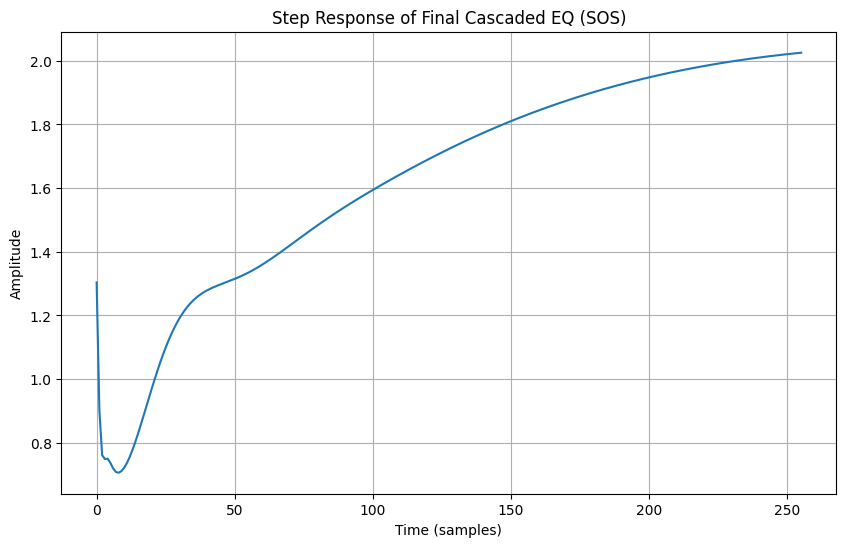

The step response appears to diverge, suggesting potential instability (unlikely for SOS).


In [ ]:
# Create a step signal (ones)
num_samples_step = 256 # Use the same number of samples as for impulse response
step_input = np.ones(num_samples_step)

# Filter the step through the cascaded SOS sections
step_response_sos_48k = sosfilt(sos_48k, step_input)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(num_samples_step), step_response_sos_48k)
plt.title('Step Response of Final Cascaded EQ (SOS)')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# A simple check for convergence, suggesting stability
if np.all(np.isfinite(step_response_sos_48k[-10:])) and np.abs(step_response_sos_48k[-1] - step_response_sos_48k[-10]) < 1e-6:
    print("The step response appears to converge, indicating the SOS cascaded filter is stable.")
else:
    print("The step response appears to diverge, suggesting potential instability (unlikely for SOS).")

In [ ]:
import pandas as pd

# Create a DataFrame from the SOS impulse and step responses
signal_data = pd.DataFrame({
    'Time_Samples': np.arange(len(impulse_response_sos_48k)),
    'SOS_Impulse_Response': impulse_response_sos_48k,
    'SOS_Step_Response': step_response_sos_48k
})

# Define the output filename
output_signal_filename = 'filtered_signal_data.csv'

# Export to CSV
signal_data.to_csv(output_signal_filename, index=False)

print(f"Filtered signal data exported to {output_signal_filename}")

# Display the head of the DataFrame for confirmation
display(signal_data.head())

Filtered signal data exported to filtered_signal_data.csv


,Time_Samples,SOS_Impulse_Response,SOS_Step_Response
0,0,1.303646,1.303646
1,1,-0.403561,0.900085
2,2,-0.139151,0.760935
3,3,-0.011986,0.748948
4,4,0.001069,0.750017


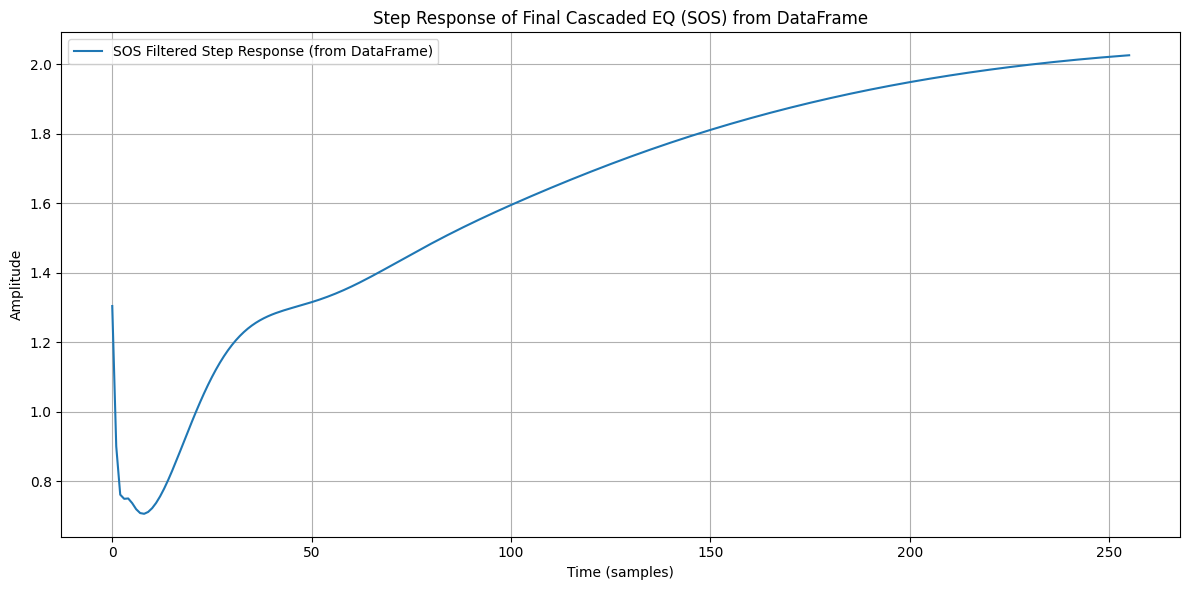

Step response plot saved to sos_step_response_from_dataframe.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(signal_data['Time_Samples'], signal_data['SOS_Step_Response'], label='SOS Filtered Step Response (from DataFrame)')
ax.set_title('Step Response of Final Cascaded EQ (SOS) from DataFrame')
ax.set_xlabel('Time (samples)')
ax.set_ylabel('Amplitude')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# Save the figure to an image file
output_image_filename = 'sos_step_response_from_dataframe.png'
fig.savefig(output_image_filename)
print(f"Step response plot saved to {output_image_filename}")

### Comparison of Original vs. Filtered Signal Data

These plots illustrate the effect of the SOS cascaded filter on an impulse signal and a step signal. The 'original' signal represents the input, and the 'filtered' signal shows the output after passing through the equalizer.

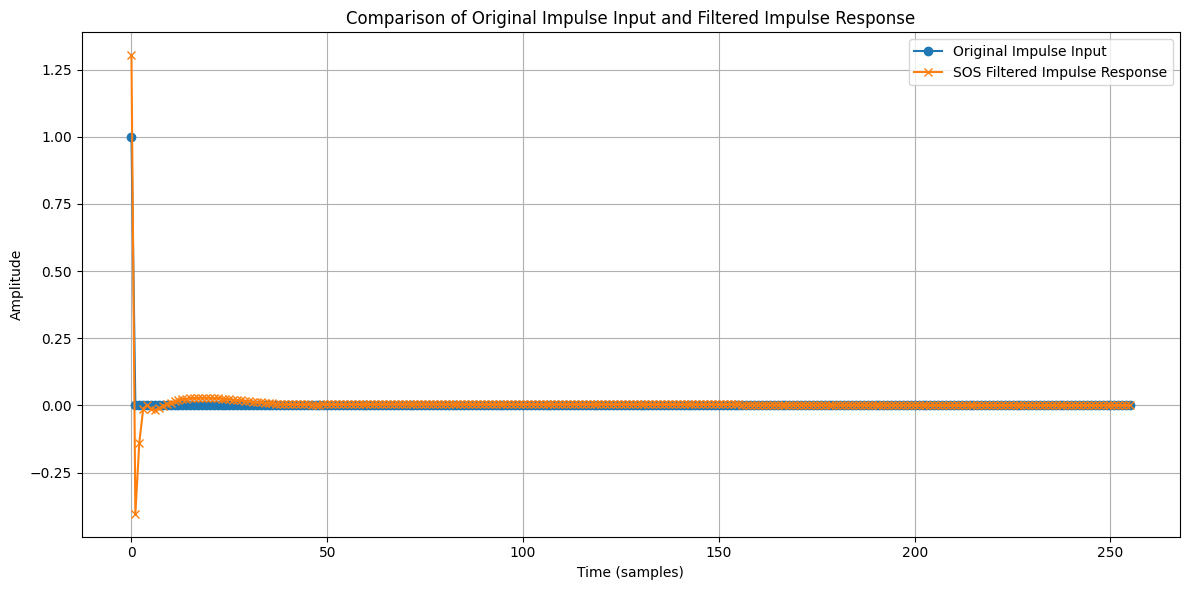

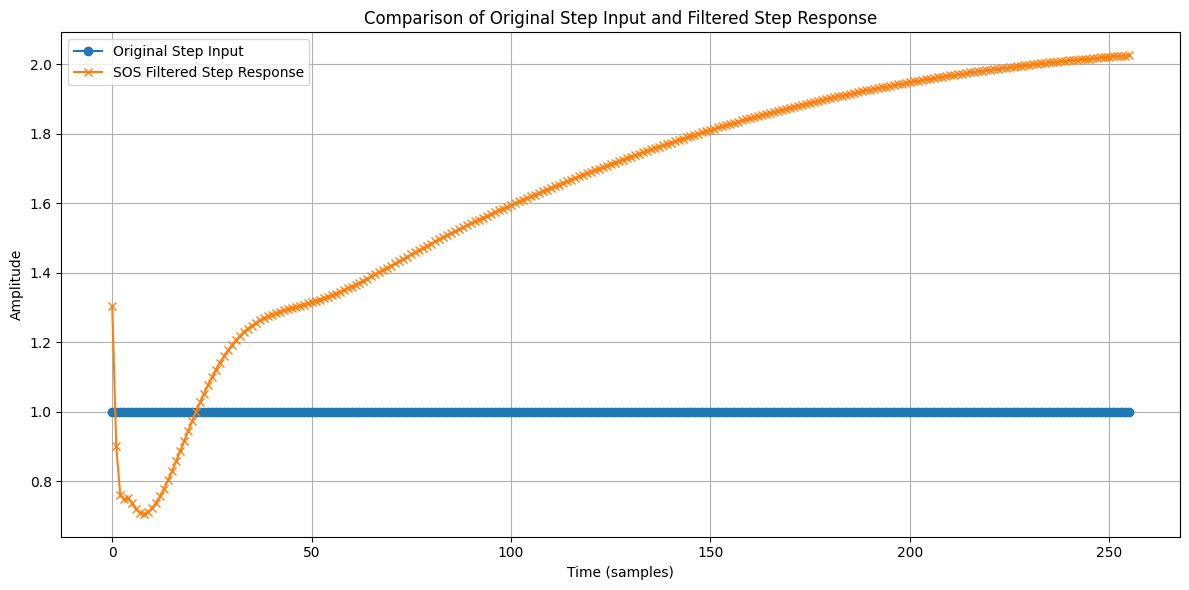

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(impulse_input)), impulse_input, 'o-', label='Original Impulse Input')
plt.plot(np.arange(len(impulse_response_sos_48k)), impulse_response_sos_48k, 'x-', label='SOS Filtered Impulse Response')
plt.title('Comparison of Original Impulse Input and Filtered Impulse Response')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(step_input)), step_input, 'o-', label='Original Step Input')
plt.plot(np.arange(len(step_response_sos_48k)), step_response_sos_48k, 'x-', label='SOS Filtered Step Response')
plt.title('Comparison of Original Step Input and Filtered Step Response')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
output_error_filename = 'error_comparison_table.csv'
df_errors.to_csv(output_error_filename, index=False)
print(f"Error comparison table exported to {output_error_filename}")

Error comparison table exported to error_comparison_table.csv


### Summary of Error Metrics

The following table summarizes the Mean Absolute Error (MAE), Maximum Absolute Error (Max AE), and Mean Squared Error (MSE) for the magnitude, phase, and group delay responses when comparing the original cascaded filter implementation with the numerically stable Second-Order Sections (SOS) implementation. These metrics confirm the high fidelity between the two approaches, demonstrating the SOS method effectively addresses stability concerns without significant deviation in filter performance.

In [ ]:
output_error_summary_filename = 'error_metrics_summary.csv'
df_errors.to_csv(output_error_summary_filename, index=False)
print(f"Error metrics summary exported to {output_error_summary_filename}")

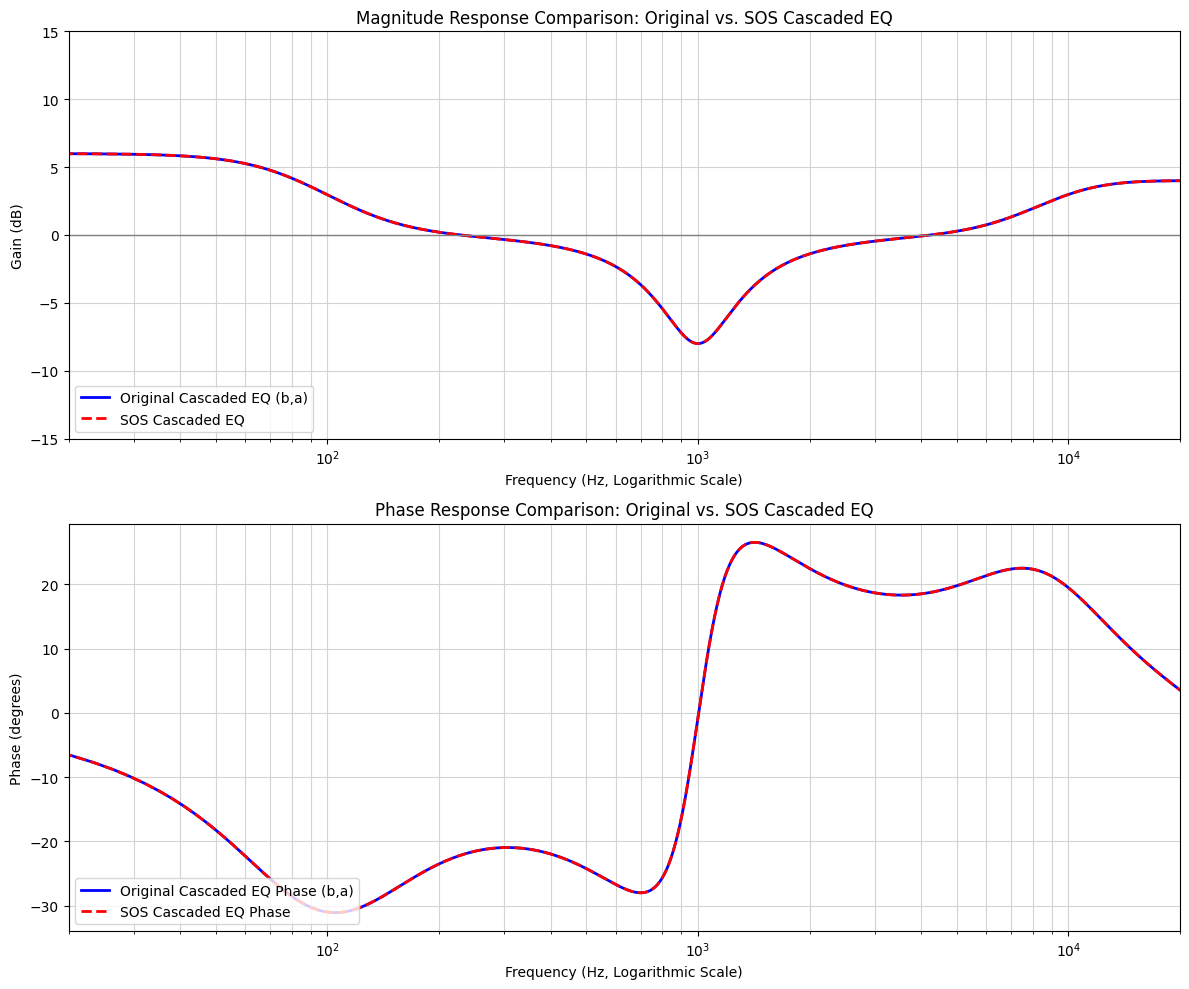

In [ ]:
# Calculate frequency response for the SOS filter
w_sos, h_total_sos_48k = signal.sosfreqz(sos_48k, worN=8192)
freq_hz_sos = w_sos * fs / (2 * np.pi)

# --- PLOTTING COMPARISON --- (Original vs. SOS)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Magnitude Response Comparison
ax1.plot(freq_hz_48k, 20 * np.log10(np.abs(h_total_48k)), color='blue', linewidth=2, label='Original Cascaded EQ (b,a)')
ax1.plot(freq_hz_sos, 20 * np.log10(np.abs(h_total_sos_48k)), color='red', linestyle='--', linewidth=2, label='SOS Cascaded EQ')

ax1.set_xscale('log')
ax1.set_xlim([20, 20000])
ax1.set_ylim([-15, 15])
ax1.set_title("Magnitude Response Comparison: Original vs. SOS Cascaded EQ")
ax1.set_xlabel("Frequency (Hz, Logarithmic Scale)")
ax1.set_ylabel("Gain (dB)")
ax1.grid(True, which="both", ls="-", color='lightgray')
ax1.axhline(0, color='gray', linewidth=1)
ax1.legend(loc="lower left")

# Phase Response Comparison
phase_total_sos_48k = np.unwrap(np.angle(h_total_sos_48k)) * 180 / np.pi

ax2.plot(freq_hz_48k, phase_total_48k, color='blue', linewidth=2, label='Original Cascaded EQ Phase (b,a)')
ax2.plot(freq_hz_sos, phase_total_sos_48k, color='red', linestyle='--', linewidth=2, label='SOS Cascaded EQ Phase')

ax2.set_xscale('log')
ax2.set_xlim([20, 20000])
ax2.set_title("Phase Response Comparison: Original vs. SOS Cascaded EQ")
ax2.set_xlabel("Frequency (Hz, Logarithmic Scale)")
ax2.set_ylabel("Phase (degrees)")
ax2.grid(True, which="both", ls="-", color='lightgray')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

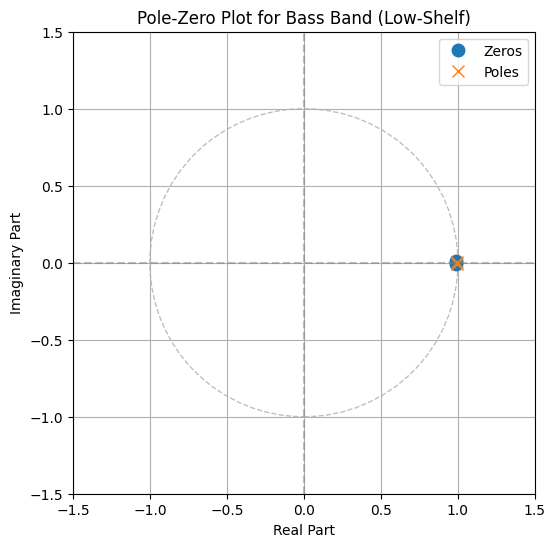

The Bass Band (Low-Shelf) filter is stable (all poles are inside the unit circle).


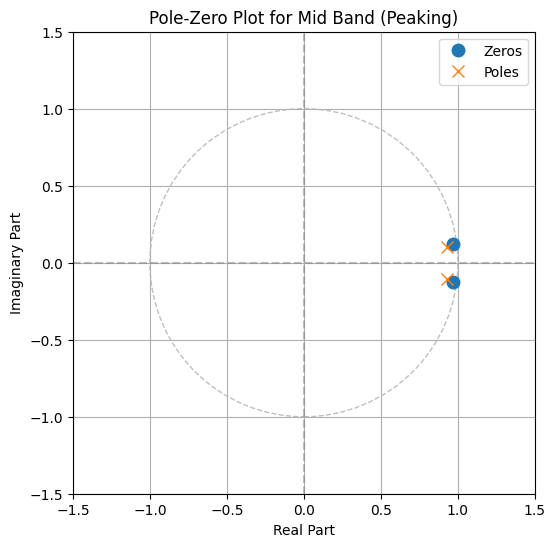

The Mid Band (Peaking) filter is stable (all poles are inside the unit circle).


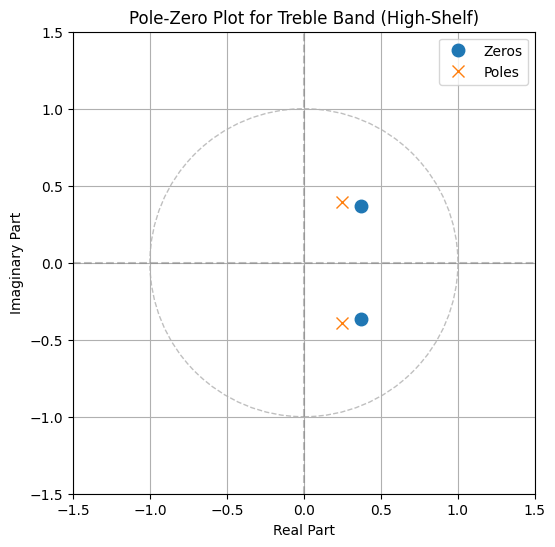

The Treble Band (High-Shelf) filter is stable (all poles are inside the unit circle).


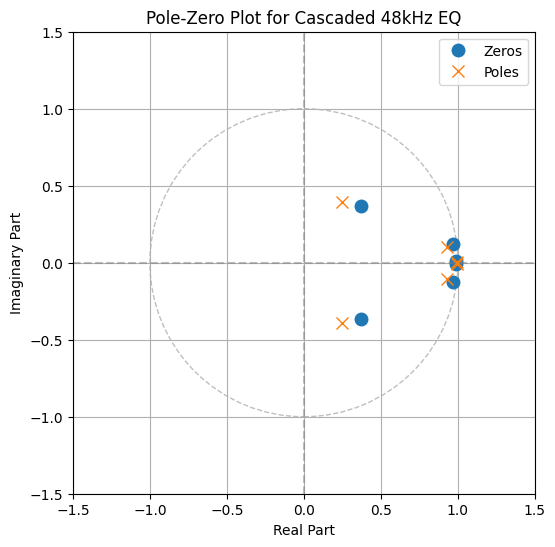

The Cascaded 48kHz EQ filter is stable (all poles are inside the unit circle).


In [ ]:
from scipy.signal import tf2zpk

def plot_zplane(b, a, title):
    """Plots the pole-zero diagram for a given filter."""
    z, p, k = tf2zpk(b, a)

    plt.figure(figsize=(6, 6))
    plt.plot(np.real(z), np.imag(z), 'o', markersize=9, label='Zeros')
    plt.plot(np.real(p), np.imag(p), 'x', markersize=9, label='Poles')

    # Plot the unit circle
    unit_circle = plt.Circle((0, 0), 1, color='gray', linestyle='--', fill=False, alpha=0.5)
    plt.gca().add_patch(unit_circle)

    plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

    plt.title(f'Pole-Zero Plot for {title}')
    plt.xlabel('Real Part')
    plt.ylabel('Imaginary Part')
    plt.xlim([-1.5, 1.5])
    plt.ylim([-1.5, 1.5])
    plt.grid(True)
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

    # Check for stability: all poles must be inside the unit circle
    unstable_poles = p[np.abs(p) > 1]
    if len(unstable_poles) == 0:
        print(f"The {title} filter is stable (all poles are inside the unit circle).")
    else:
        print(f"The {title} filter is unstable! Poles outside the unit circle: {unstable_poles}")

# Plot for each filter band
plot_zplane(b_bass, a_bass, 'Bass Band (Low-Shelf)')
plot_zplane(b_mid, a_mid, 'Mid Band (Peaking)')
plot_zplane(b_treble, a_treble, 'Treble Band (High-Shelf)')

# Plot for the cascaded filter
plot_zplane(b_total_48k, a_total_48k, 'Cascaded 48kHz EQ')

Maximum group delay difference between 48kHz and 44.1kHz is: 0.2025 ms


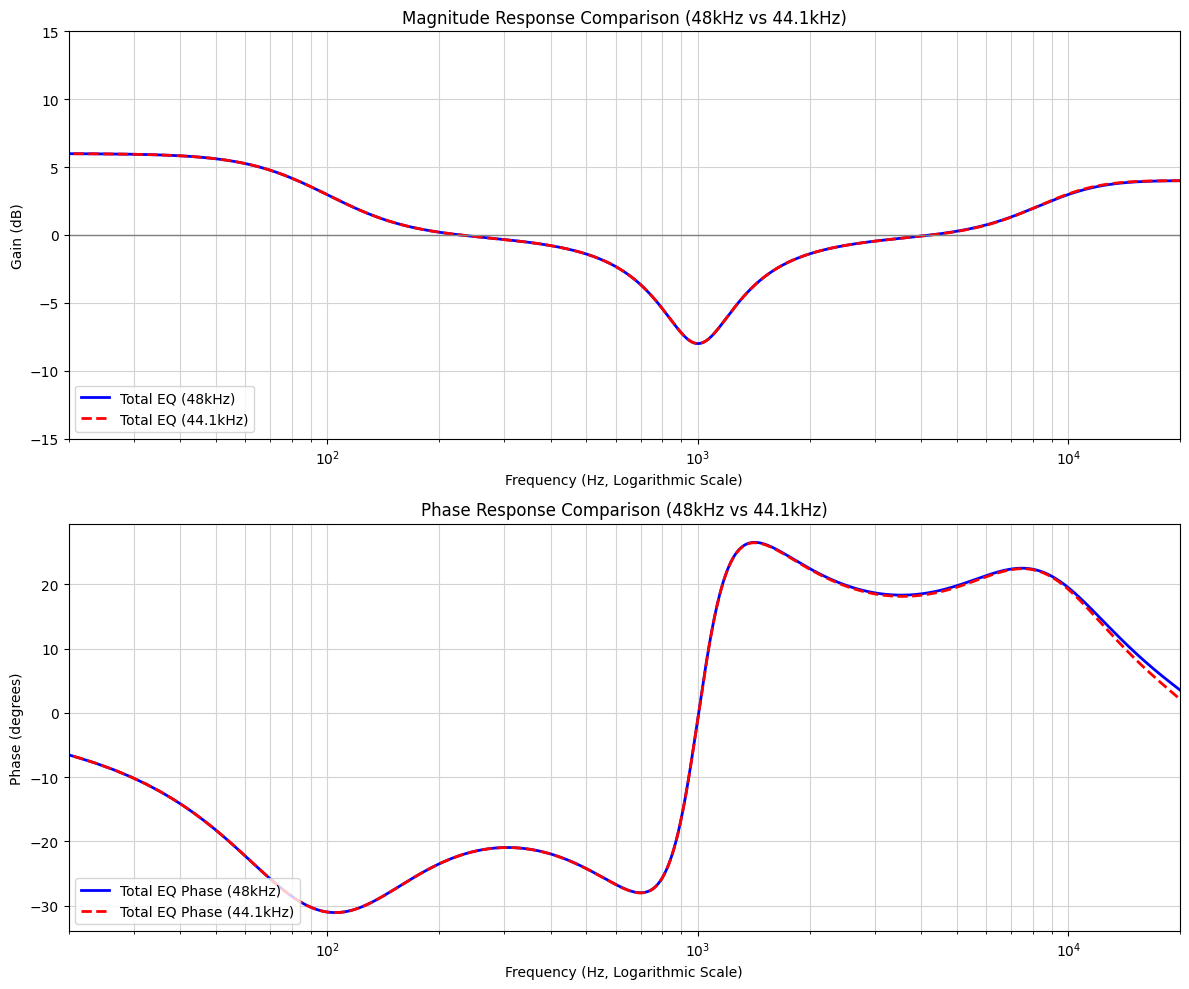

In [ ]:
def calculate_filter_responses(fs_val):
    # --- 1. CONFIGURATION SYSTEM ---
    # Define the user settings for our 3 bands (keeping them constant for comparison)
    bass_freq, bass_gain   = 100,   6.0   # +6 dB boost at 100 Hz
    mid_freq,  mid_gain, mid_Q = 1000, -8.0, 1.5 # -8 dB cut at 1 kHz (Narrow Q)
    treble_freq, treble_gain = 8000,  4.0   # +4 dB boost at 8 kHz

    # --- 2. GENERATE FILTER COEFFICIENTS ---
    b_bass, a_bass     = low_shelf_coefficients(bass_freq, bass_gain, fs_val)
    b_mid, a_mid       = peaking_eq_coefficients(mid_freq, mid_gain, mid_Q, fs_val)
    b_treble, a_treble = high_shelf_coefficients(treble_freq, treble_gain, fs_val)

    # --- 3. COMPUTE SPECTRAL RESPONSES ---
    w, h_bass   = signal.freqz(b_bass, a_bass, worN=8192)
    _, h_mid    = signal.freqz(b_mid, a_mid, worN=8192)
    _, h_treble = signal.freqz(b_treble, a_treble, worN=8192)

    # Cascade Step: Multiply complex frequency vectors to get the aggregate system response
    h_total = h_bass * h_mid * h_treble
    freq_hz = w * fs_val / (2 * np.pi)

    return freq_hz, h_total, b_bass, a_bass, b_mid, a_mid, b_treble, a_treble, w

# Calculate responses for the current fs (48000 Hz)
fs_48k = fs # fs is already 48000 from the previous cell
freq_hz_48k, h_total_48k, b_bass_48k, a_bass_48k, b_mid_48k, a_mid_48k, b_treble_48k, a_treble_48k, w_48k = calculate_filter_responses(fs_48k)

# Calculate responses for the new fs (44100 Hz)
fs_44_1k = 44100
freq_hz_44_1k, h_total_44_1k, b_bass_44_1k, a_bass_44_1k, b_mid_44_1k, a_mid_44_1k, b_treble_44_1k, a_treble_44_1k, w_44_1k = calculate_filter_responses(fs_44_1k)

# Calculate group delays for 48kHz
_, gd_bass_48k = signal.group_delay((b_bass_48k, a_bass_48k), w_48k)
_, gd_mid_48k = signal.group_delay((b_mid_48k, a_mid_48k), w_48k)
_, gd_treble_48k = signal.group_delay((b_treble_48k, a_treble_48k), w_48k)
gd_total_48k_samples = gd_bass_48k + gd_mid_48k + gd_treble_48k
gd_total_48k_ms = gd_total_48k_samples * 1000 / fs_48k

# Calculate group delays for 44.1kHz
_, gd_bass_44_1k = signal.group_delay((b_bass_44_1k, a_bass_44_1k), w_44_1k)
_, gd_mid_44_1k = signal.group_delay((b_mid_44_1k, a_mid_44_1k), w_44_1k)
_, gd_treble_44_1k = signal.group_delay((b_treble_44_1k, a_treble_44_1k), w_44_1k)
gd_total_44_1k_samples = gd_bass_44_1k + gd_mid_44_1k + gd_treble_44_1k
gd_total_44_1k_ms = gd_total_44_1k_samples * 1000 / fs_44_1k

# Ensure both group delay arrays have the same length for element-wise comparison
# This assumes that the frequency arrays (w_48k and w_44_1k) generated by freqz/group_delay
# have roughly the same range and number of points, or we need to resample/interpolate.
# For now, let's truncate to the minimum length.
min_len_gd = min(len(gd_total_48k_ms), len(gd_total_44_1k_ms))

difference_gd_ms = np.abs(gd_total_48k_ms[:min_len_gd] - gd_total_44_1k_ms[:min_len_gd])
max_gd_difference = np.max(difference_gd_ms)

print(f"Maximum group delay difference between 48kHz and 44.1kHz is: {max_gd_difference:.4f} ms")

# --- PLOTTING COMPARISON ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Magnitude Response Comparison
ax1.plot(freq_hz_48k, 20 * np.log10(np.abs(h_total_48k)), color='blue', linewidth=2, label=f'Total EQ (48kHz)')
ax1.plot(freq_hz_44_1k, 20 * np.log10(np.abs(h_total_44_1k)), color='red', linestyle='--', linewidth=2, label=f'Total EQ (44.1kHz)')

ax1.set_xscale('log')
ax1.set_xlim([20, 20000])
ax1.set_ylim([-15, 15])
ax1.set_title("Magnitude Response Comparison (48kHz vs 44.1kHz)")
ax1.set_xlabel("Frequency (Hz, Logarithmic Scale)")
ax1.set_ylabel("Gain (dB)")
ax1.grid(True, which="both", ls="-", color='lightgray')
ax1.axhline(0, color='gray', linewidth=1)
ax1.legend(loc="lower left")

# Phase Response Comparison
phase_total_48k = np.unwrap(np.angle(h_total_48k)) * 180 / np.pi
phase_total_44_1k = np.unwrap(np.angle(h_total_44_1k)) * 180 / np.pi

ax2.plot(freq_hz_48k, phase_total_48k, color='blue', linewidth=2, label=f'Total EQ Phase (48kHz)')
ax2.plot(freq_hz_44_1k, phase_total_44_1k, color='red', linestyle='--', linewidth=2, label=f'Total EQ Phase (44.1kHz)')

ax2.set_xscale('log')
ax2.set_xlim([20, 20000])
ax2.set_title("Phase Response Comparison (48kHz vs 44.1kHz)")
ax2.set_xlabel("Frequency (Hz, Logarithmic Scale)")
ax2.set_ylabel("Phase (degrees)")
ax2.grid(True, which="both", ls="-", color='lightgray')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Combine coefficients into a dictionary for easy DataFrame creation
coefficients_data = {
    'b_bass': b_bass,
    'a_bass': a_bass,
    'b_mid': b_mid,
    'a_mid': a_mid,
    'b_treble': b_treble,
    'a_treble': a_treble
}

# Pad shorter arrays with NaN to ensure all arrays have the same length
max_len = max(len(arr) for arr in coefficients_data.values())
padded_coefficients = {k: np.pad(v, (0, max_len - len(v)), 'constant', constant_values=np.nan) for k, v in coefficients_data.items()}

# Create a DataFrame
df_coefficients = pd.DataFrame(padded_coefficients)

# Export to CSV
output_filename = 'filter_coefficients.csv'
df_coefficients.to_csv(output_filename, index=False)

print(f"Filter coefficients exported to {output_filename}")
print(df_coefficients.head())

Filter coefficients exported to filter_coefficients.csv
     b_bass    a_bass     b_mid     a_mid  b_treble  a_treble
0  1.003503  1.000000  0.958000  1.000000  1.334736  1.000000
1 -1.982974 -1.983044 -1.841588 -1.841588 -0.842851 -0.381216
2  0.979754  0.983187  0.902439  0.860439  0.324211  0.197311
